# 02b — Cross-Camera Timing Calibration
Scans a session folder of multi-camera videos, probes each file,
detects metadata issues, builds per-camera timelines, computes
motion-energy signals, cross-correlates to find temporal offsets,
and produces a unified synchronized frame index.

## How it works

1. **Probe** — Counts actual frames via `ffprobe -count_frames` (required for ASF
   files where PTS is unavailable and container duration is unreliable).
2. **Quality** — Flags any mismatch between metadata frame count and actual frames.
3. **Timestamps** — Parses wall-clock times from filenames (`HHMMSS-C.ASF`).
4. **Timelines** — Builds a continuous recording interval per camera.
5. **Motion** — Decodes a subset of frames via `ffmpeg` pipe and computes
   frame-to-frame pixel differences (motion energy).
6. **Synchronize** — Cross-correlates motion signals between camera pairs
   that have overlapping recording windows.
7. **Export** — Saves a unified frame index CSV, a calibration JSON, a
   summary text file, and a timeline visualization.

In [1]:
# ===== CONFIGURATION =====

GITHUB_REPO_URL = "https://github.com/kaarthik-balakrishnan/LightningPoseTrack.git"
GIT_BRANCH = "main"

# Google Drive root
DRIVE_ROOT = "/content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior"
OUTPUT_ROOT = "/content/drive/MyDrive/LightningPoseTrack/260608.00000009"

# Path to a session folder containing multi-camera video files.
# The pipeline scans recursively for .ASF, .mp4, .avi, .mov, .mkv files.
# Set this to the folder you want to calibrate.
SESSION_FOLDER = f"{DRIVE_ROOT}/260608.00000009"

# Number of frames to decode for motion analysis (per file).
# Higher = more accurate sync but slower. 300-500 is a good balance.
MOTION_MAX_FRAMES = 300

# Output subdirectory name (inside SESSION_FOLDER)
OUTPUT_DIR_NAME = "calibration_output"

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
import os, sys

REPO_DIR = "/content/LightningPoseTrack"
if not os.path.exists(REPO_DIR):
    !git clone {GITHUB_REPO_URL} {REPO_DIR}
else:
    %cd {REPO_DIR}
    !git pull
%cd {REPO_DIR}
sys.path.insert(0, REPO_DIR)

print(f"Repository ready at {REPO_DIR}")

Cloning into '/content/LightningPoseTrack'...
remote: Enumerating objects: 1333, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 1333 (delta 56), reused 51 (delta 20), pack-reused 1237 (from 1)
Receiving objects: 100% (1333/1333), 336.69 MiB | 37.45 MiB/s, done.
Resolving deltas: 100% (230/230), done.
/content/LightningPoseTrack
Repository ready at /content/LightningPoseTrack


In [4]:
!pip install --quiet numpy pandas matplotlib

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

print("Dependencies installed.")
print(f"  numpy {np.__version__}")
print(f"  matplotlib {matplotlib.__version__}")

Dependencies installed.
  numpy 2.0.2
  matplotlib 3.10.0


---
## Stage 1 — Run the Calibration Pipeline

In [5]:
from src.calibration.pipeline import CalibrationPipeline

import time
t0 = time.time()

pipe = CalibrationPipeline(SESSION_FOLDER)

# ---- Stage 1: Scan ----
print("=" * 60)
print("Stage 1/9: Scan")
print("=" * 60)
pipe.scan()

# ---- Stage 2: Probe ----
print("=" * 60)
print("Stage 2/9: Probe")
print("=" * 60)
pipe.probe()

# ---- Stage 3: Quality ----
print("=" * 60)
print("Stage 3/9: Quality")
print("=" * 60)
pipe.quality()

# ---- Stage 4: Parse timestamps ----
print("=" * 60)
print("Stage 4/9: Parse timestamps")
print("=" * 60)
pipe.parse_timestamps()

# ---- Stage 5: Build timelines ----
print("=" * 60)
print("Stage 5/9: Build timelines")
print("=" * 60)
pipe.build_timelines()

# ---- Stage 6: Motion ----
print("=" * 60)
print("Stage 6/9: Motion")
print("=" * 60)
pipe.compute_motion(max_frames=MOTION_MAX_FRAMES)

# ---- Stage 7: Synchronize ----
print("=" * 60)
print("Stage 7/9: Synchronize")
print("=" * 60)
pipe.synchronize()

# ---- Stage 8: Export ----
print("=" * 60)
print("Stage 8/9: Export")
print("=" * 60)
output_dir = str(Path(OUTPUT_ROOT) / OUTPUT_DIR_NAME)
pipe.export(output_dir=output_dir)

elapsed = time.time() - t0
print(f"\nPipeline complete in {elapsed:.1f}s")

Stage 1/9: Scan

────────────────────────────────────────────────────────────
Stage 1/9: Scan — Finding video files
────────────────────────────────────────────────────────────
  Found 127 video files in /content/drive/Shareddrives/3R.Data/1P.SPRIND.Data/POC/Behavior/260608.00000009
    004653-4.ASF
    004657-3.ASF
    004659-2.ASF
    004703-1.ASF
    004756-2.ASF
    004757-3.ASF
    004818-4.ASF
    014853-4.ASF
    015156-4.ASF
    015201-3.ASF
    015206-2.ASF
    015213-1.ASF
    015543-4.ASF
    035426-4.ASF
    035429-3.ASF
    035430-2.ASF
    035433-1.ASF
    035603-2.ASF
    035605-3.ASF
    035612-4.ASF
    044929-4.ASF
    054557-4.ASF
    054659-4.ASF
    055733-4.ASF
    055945-4.ASF
    060235-3.ASF
    060244-2.ASF
    060300-1.ASF
    061556-1.ASF
    061735-2.ASF
    061736-3.ASF
    061754-4.ASF
    062432-4.ASF
    062606-4.ASF
    062751-4.ASF
    063139-4.ASF
    063211-3.ASF
    063235-2.ASF
    063449-2.ASF
    063526-3.ASF
    063544-1.ASF
    063746-2.ASF
  

---
## Results Summary

In [6]:
# ---- Probe summary ----
df_probe = pd.DataFrame(pipe.results)
if "error" in df_probe.columns:
    n_ok = df_probe["error"].isna().sum()
    n_err = df_probe["error"].notna().sum()
else:
    n_ok = len(df_probe)
    n_err = 0

print(f"Files: {n_ok} OK, {n_err} failed")
print()

display_cols = ["filename", "camera", "fps", "frame_count",
                "duration_sec", "size_mb"]
display_cols = [c for c in display_cols if c in df_probe.columns]
df_probe[display_cols]

Files: 127 OK, 0 failed



,filename,camera,fps,frame_count,duration_sec,size_mb
0,004653-4.ASF,4,10.00,602,60.200,13.3
1,004657-3.ASF,3,10.00,576,57.600,14.3
2,004659-2.ASF,2,10.25,607,59.220,15.6
3,004703-1.ASF,1,10.25,961,93.756,26.6
4,004756-2.ASF,2,10.25,604,58.927,15.6
...,...,...,...,...,...,...
122,090307-2.ASF,2,10.25,983,95.902,32.0
123,090314-1.ASF,1,10.25,645,62.927,19.8
124,090409-4.ASF,4,5.00,1357,271.400,38.3
125,090715-3.ASF,3,10.00,1002,100.200,24.4


In [7]:
# ---- Calibration offsets ----
print("Cross-Camera Calibration Offsets")
print("-" * 40)
if pipe.offsets:
    for pair, offset in sorted(pipe.offsets.items()):
        status = f"{offset:.3f}s" if offset is not None else "NO DATA"
        cams = pair.split("_to_")
        print(f"  Camera {cams[1]} relative to Camera {cams[0]}: {status}")
else:
    print("  (no offset data)")
print()

# Frame index size
csv_path = Path(str(output_dir) + "/unified_timeline.csv")
if csv_path.exists():
    n_rows = sum(1 for _ in open(csv_path)) - 1
    print(f"Unified frame index: {n_rows:,} rows saved to {csv_path}")

Cross-Camera Calibration Offsets
----------------------------------------
  Camera 2 relative to Camera 1: -7898.400s
  Camera 3 relative to Camera 1: -7941.300s
  Camera 4 relative to Camera 1: -8650.100s
  Camera 3 relative to Camera 2: -36.300s
  Camera 4 relative to Camera 2: -822.800s
  Camera 4 relative to Camera 3: -772.700s

Unified frame index: 142,338 rows saved to /content/drive/MyDrive/LightningPoseTrack/260608.00000009/calibration_output/unified_timeline.csv


---
## Timeline Visualization

Generating timeline overview plot ...


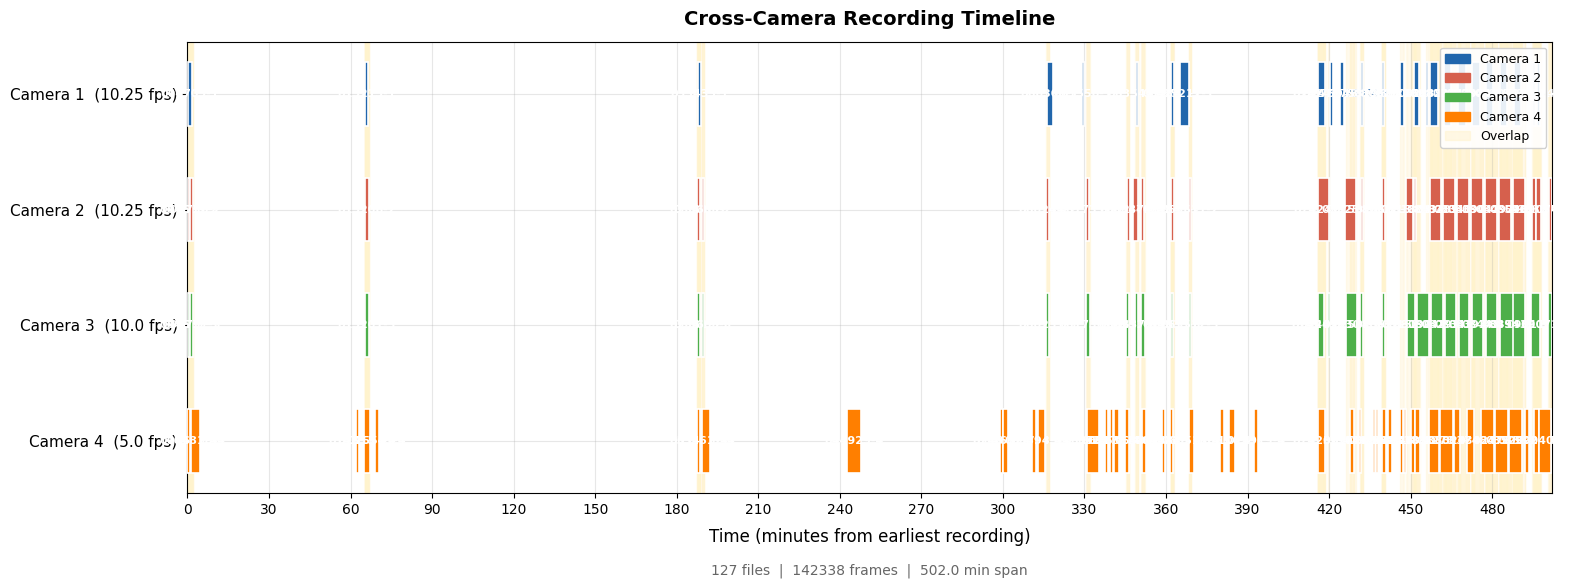

Saved to /content/drive/MyDrive/LightningPoseTrack/260608.00000009/calibration_output/timeline_overview.png

────────────────────────────────────────────────────────────
Stage 9/9: Visualize — Generating timeline overview plot
────────────────────────────────────────────────────────────
  Timeline plot: /content/drive/MyDrive/LightningPoseTrack/260608.00000009/calibration_output/timeline_overview.png


In [8]:
print("Generating timeline overview plot ...")

CAMERA_COLORS = {
    1: "#2166AC",
    2: "#D6604D",
    3: "#4DAF4A",
    4: "#FF7F00",
}

CAMERA_NAMES = {
    1: "Camera 1  (10.25 fps)",
    2: "Camera 2  (10.25 fps)",
    3: "Camera 3  (10.0 fps)",
    4: "Camera 4  (5.0 fps)",
}

# Build interval data from pipeline timelines
files = []
for cam, tl in pipe.timelines.items():
    for entry in tl:
        files.append({
            "camera": cam,
            "filename": entry["filename"],
            "start": entry["start_time_abs"],
            "end": entry["end_time_rel"] + tl[0]["start_time_abs"],
            "frames": entry["frame_count"],
            "fps": entry["fps"],
        })

if not files:
    print("No timeline data to plot.")
else:
    t_min = min(f["start"] for f in files)
    t_max = max(f["end"] for f in files)
    total_min = (t_max - t_min) / 60

    for f in files:
        f["start_min"] = (f["start"] - t_min) / 60
        f["end_min"] = (f["end"] - t_min) / 60

    fig, ax = plt.subplots(figsize=(16, 6))
    cameras = sorted(set(f["camera"] for f in files))
    y_positions = {cam: i for i, cam in enumerate(cameras[::-1])}

    for f in files:
        y = y_positions[f["camera"]]
        c = CAMERA_COLORS.get(f["camera"], "#888888")
        dur = max(f["end_min"] - f["start_min"], 0.01)
        ax.barh(y, dur, left=f["start_min"], height=0.55,
                color=c, edgecolor="white", linewidth=1.2, zorder=3)
        label = f["filename"]
        if "." in label:
            label = label.rsplit(".", 1)[0]
        if dur > 0.7:
            ax.text(f["start_min"] + dur / 2, y, label,
                    ha="center", va="center", fontsize=8,
                    color="white", fontweight="bold")
        else:
            ax.text(f["end_min"] + 0.03, y, label,
                    ha="left", va="center", fontsize=7.5, color=c)

    # Overlap highlights
    overlap_regions = []
    for i, cam_a in enumerate(cameras):
        for cam_b in cameras[i + 1:]:
            for fa in files:
                if fa["camera"] != cam_a:
                    continue
                for fb in files:
                    if fb["camera"] != cam_b:
                        continue
                    ov_start = max(fa["start_min"], fb["start_min"])
                    ov_end = min(fa["end_min"], fb["end_min"])
                    if ov_end - ov_start > 0.01:
                        overlap_regions.append((ov_start, ov_end))

    for ov_start, ov_end in overlap_regions:
        ax.axvspan(ov_start, ov_end, color="#FFF3CD", alpha=0.35, zorder=0)

    if overlap_regions:
        unique_overlaps = list(set(
            (round(s, 2), round(e, 2)) for s, e in overlap_regions
        ))
        for ov_start, ov_end in sorted(unique_overlaps):
            mid_x = (ov_start + ov_end) / 2
            dur_s = (ov_end - ov_start) * 60
            ax.annotate(f"{dur_s:.0f}s overlap",
                        xy=(mid_x, len(cameras) - 0.3),
                        fontsize=7.5, ha="center", color="#856404",
                        style="italic",
                        bbox=dict(boxstyle="round,pad=0.2",
                                  facecolor="#FFF3CD",
                                  edgecolor="#FFC107", alpha=0.85))

    ax.set_yticks(list(y_positions.values()))
    ax.set_yticklabels([CAMERA_NAMES.get(cam, f"Camera {cam}")
                        for cam in cameras[::-1]], fontsize=11)
    ax.set_xlabel("Time (minutes from earliest recording)",
                  fontsize=12, labelpad=8)
    ax.set_title("Cross-Camera Recording Timeline",
                 fontsize=14, fontweight="bold", pad=12)
    ax.set_xlim(-0.1, total_min + 0.1)

    # Dynamic tick interval based on total span
    if total_min < 10:
        major_interval = 1
    elif total_min < 30:
        major_interval = 2
    elif total_min < 60:
        major_interval = 5
    elif total_min < 180:
        major_interval = 10
    elif total_min < 360:
        major_interval = 20
    elif total_min < 720:
        major_interval = 30
    else:
        major_interval = 60
    ax.xaxis.set_major_locator(plt.MultipleLocator(major_interval))
    ax.grid(True, alpha=0.3)

    # Legend
    patches = [mpatches.Patch(color=CAMERA_COLORS[c], label=f"Camera {c}")
               for c in sorted(CAMERA_COLORS) if c in cameras]
    patches.append(mpatches.Patch(color="#FFF3CD", alpha=0.5,
                                   label="Overlap"))
    ax.legend(handles=patches, loc="upper right", framealpha=0.9,
              fontsize=9)

    # Info bar
    total_frames = sum(f["frames"] for f in files)
    info = (f"{len(files)} files  |  {total_frames} frames  |  "
            f"{total_min:.1f} min span")
    ax.text(0.5, -0.18, info, transform=ax.transAxes,
            ha="center", fontsize=10, color="#666666")

    plt.tight_layout()
    viz_path = Path(str(output_dir) + "/timeline_overview.png")
    fig.savefig(viz_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved to {viz_path}")

# Also save via pipeline's built-in plot method
pipe.plot_timeline(output_path=str(Path(output_dir) / "timeline_overview.png"))


---
## Custom Time Range Visualization
To zoom into a specific time window, set `START_SEC` and `END_SEC`
(seconds since midnight) and re-run the cell below.

Plotting timeline from 08:00:00 to 09:00:00 ...

────────────────────────────────────────────────────────────
Stage 9/9: Visualize — Generating timeline overview plot
────────────────────────────────────────────────────────────
  Timeline plot: /tmp/calibration_output/timeline_custom.png


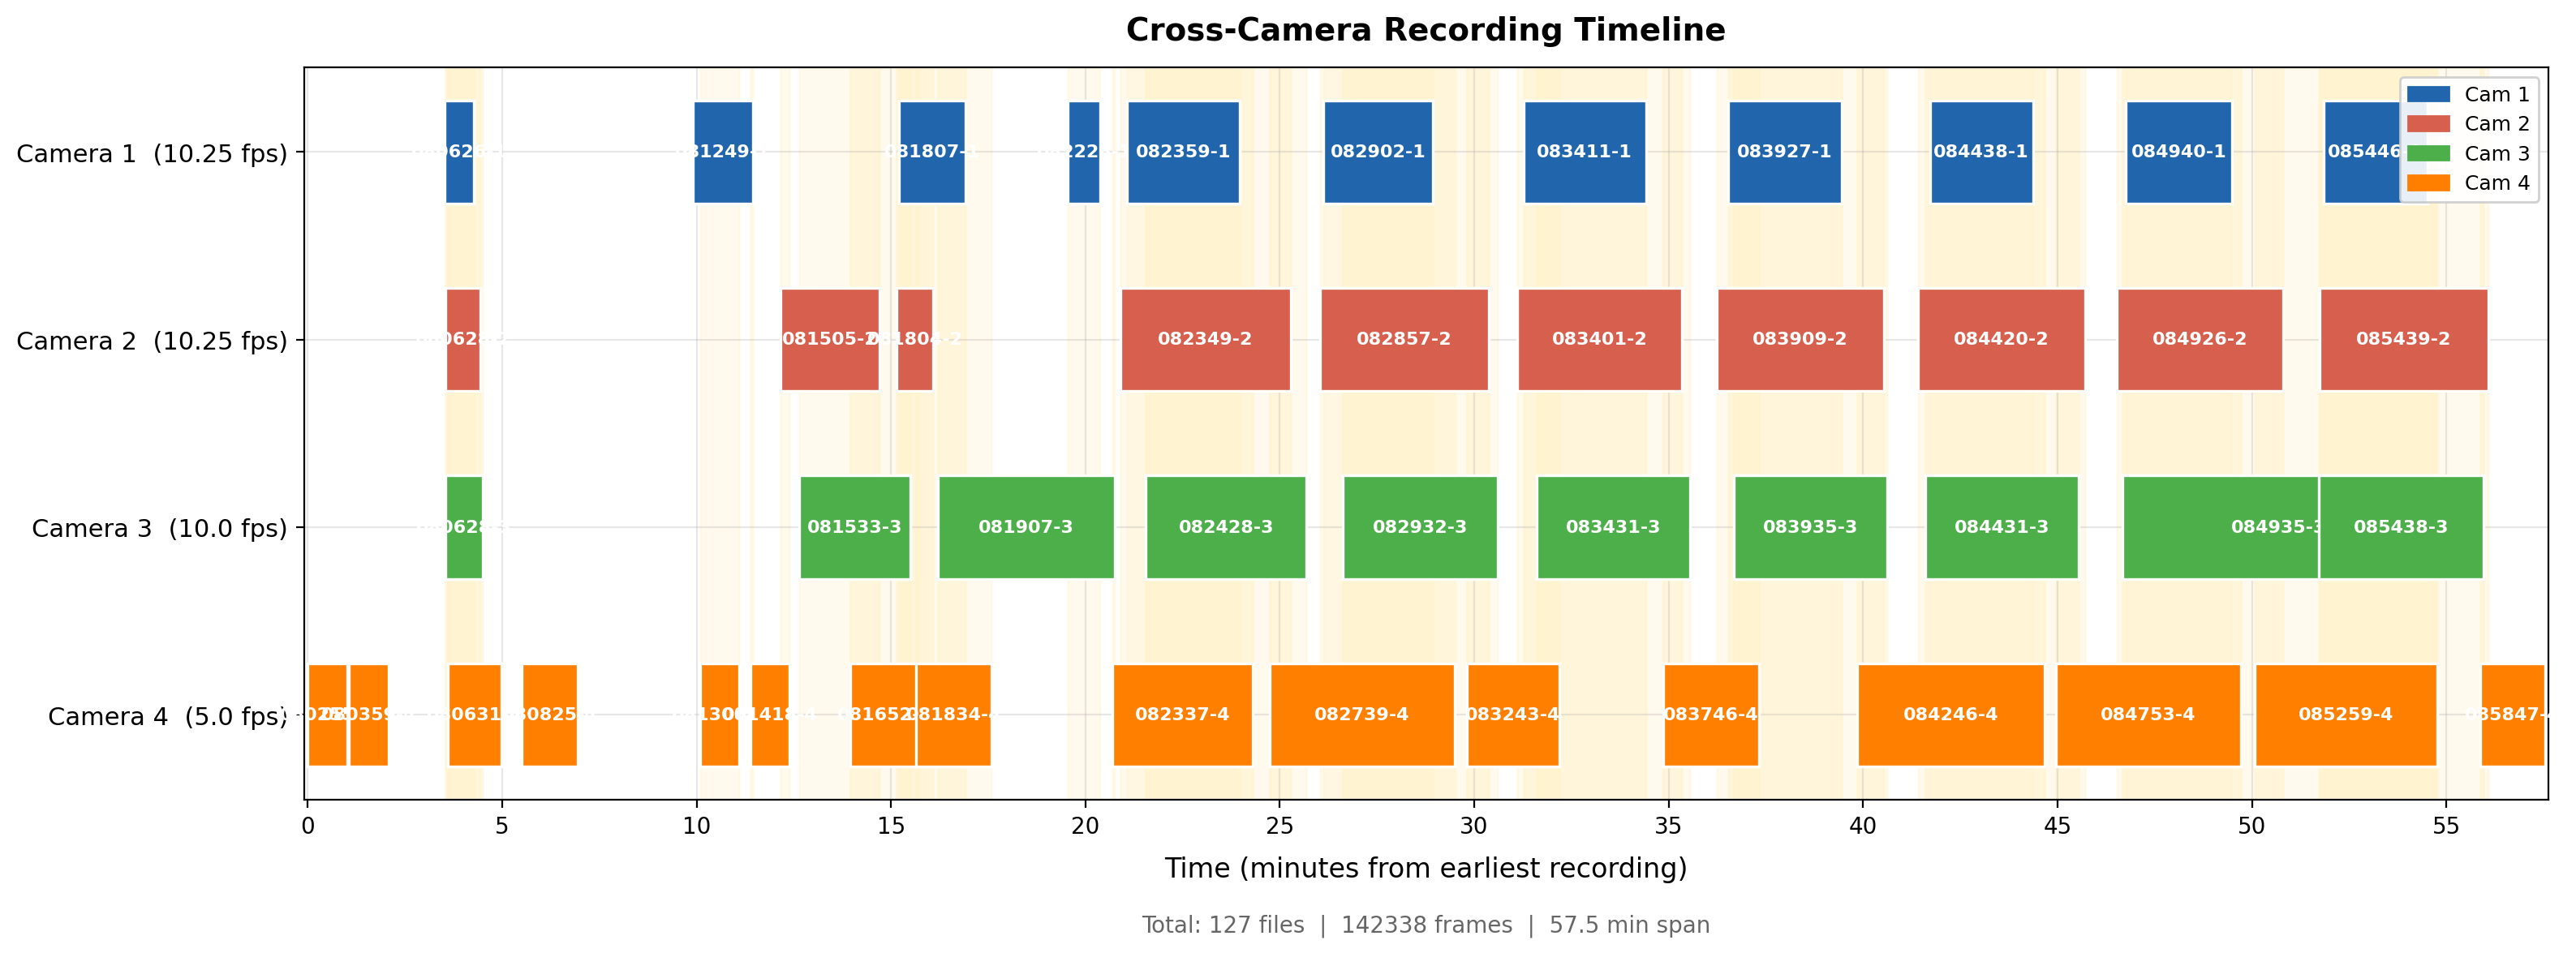

In [10]:
# ===== CUSTOM TIME RANGE (seconds since midnight) =====
# Example: 08:00 to 09:00 hours
START_SEC = 8 * 3600      # 08:00:00
END_SEC   = 9 * 3600      # 09:00:00
CUSTOM_OUTPUT = "/tmp/calibration_output/timeline_custom.png"

import matplotlib.pyplot as plt
print(f"Plotting timeline from {START_SEC//3600:02d}:{(START_SEC%3600)//60:02d}:{START_SEC%60:02d} "
      f"to {END_SEC//3600:02d}:{(END_SEC%3600)//60:02d}:{END_SEC%60:02d} ...")
pipe.plot_timeline(output_path=CUSTOM_OUTPUT,
                   start_time=START_SEC, end_time=END_SEC)
from IPython.display import Image, display
display(Image(CUSTOM_OUTPUT))

---
## Exported Files

In [11]:
output_dir_path = Path(str(output_dir))
if output_dir_path.exists():
    print(f"Output directory: {output_dir_path}")
    print()
    for p in sorted(output_dir_path.iterdir()):
        size = p.stat().st_size
        if size > 1024 * 1024:
            size_str = f"{size / 1024 / 1024:.1f} MB"
        elif size > 1024:
            size_str = f"{size / 1024:.1f} KB"
        else:
            size_str = f"{size} B"
        print(f"  {p.name}  ({size_str})")
else:
    print("No output directory found. Did the pipeline complete?")

Output directory: /content/drive/MyDrive/LightningPoseTrack/260608.00000009/calibration_output

  calibration_result.json  (20.5 MB)
  summary.txt  (12.8 KB)
  timeline_overview.png  (159.4 KB)
  unified_timeline.csv  (5.2 MB)


---
## Interpretation

- **Frame count mismatches**: Every ASF file in this dataset has an incorrect
  metadata frame count (because `format.duration` in the ASF container is
  unreliable). The pipeline uses `ffprobe -count_frames`, which decodes and
  counts every frame, giving the true count.
- **Calibration offsets**: Positive offset means the second camera starts
  *later* than the reference camera according to cross-correlation of motion
  signals. This refines the filename-based alignment (which has 1-second
  resolution).
- **Overlap windows**: Shaded yellow regions indicate time periods where
  two or more cameras were recording simultaneously. These windows are used
  for cross-correlation.
- **Unified frame index**: The CSV in `calibration_output/` maps every frame
  across all cameras to a common timeline (`time_abs`), enabling synchronized
  multi-view analysis.